In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from openTSNE import affinity

In [ ]:
from text_visualizations._cne import NeighborTransformData, NeighborTransformIndices, FastTensorDataLoader

# Test

## Toy data

<matplotlib.collections.PathCollection>

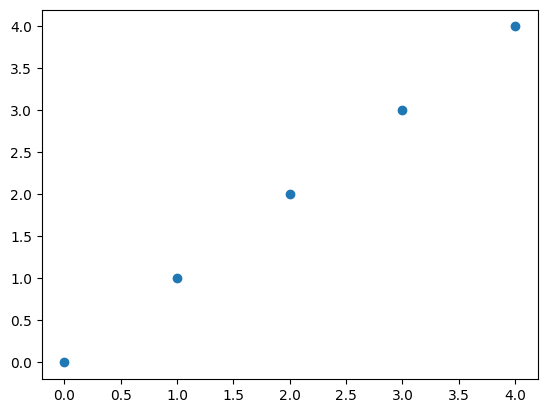

In [ ]:
x=np.arange(5)
plt.scatter(x,x)

In [ ]:
test_data= np.vstack((x,x)).T +1
test_data.shape
print(test_data)

[[1 1]
 [2 2]
 [3 3]
 [4 4]
 [5 5]]


In [ ]:
A = affinity.Uniform(
    test_data,
    verbose=True,
    random_state=42,
    k_neighbors=2,
    symmetrize=False,
)

===> Finding 2 nearest neighbors using exact search using euclidean distance...
   --> Time elapsed: 0.00 seconds


In [ ]:
A_test = A.P.todense()*10
print(A_test)

[[0. 1. 1. 0. 0.]
 [1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 1. 0.]]


In [ ]:
from scipy.sparse import diags, csr_matrix

ones_diag = diags([1], [0], shape=(A.P.shape[0],A.P.shape[1]), format='csr')  # CSR diagonal matrix of ones
A_plus_one = A.P + ones_diag  # Add matrices (result remains CSR)

In [ ]:
print(A_plus_one.todense())

[[1. 1. 1. 0. 0.]
 [1. 1. 1. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 1. 1. 1.]]


In [ ]:
# if symmetrized
A.P.todense()

matrix([[0.  , 0.1 , 0.05, 0.  , 0.  ],
        [0.1 , 0.  , 0.1 , 0.  , 0.  ],
        [0.05, 0.1 , 0.  , 0.1 , 0.05],
        [0.  , 0.  , 0.1 , 0.  , 0.1 ],
        [0.  , 0.  , 0.05, 0.1 , 0.  ]])

## Dataset and loader

In [ ]:
dataset_test = NeighborTransformData(test_data, A_test,random_state=42)

In [ ]:
import torch

gen = torch.Generator()
gen.manual_seed(42)
training_loader = torch.utils.data.DataLoader(dataset_test, batch_size=2, shuffle=True, generator=gen)

In [ ]:
%%time
dataset_test = NeighborTransformData(test_data, A_test,random_state=42)
training_loader = torch.utils.data.DataLoader(dataset_test, batch_size=2, shuffle=True, generator=gen)

for i, elem in enumerate(training_loader):
    print(elem)

[tensor([[1., 1.],
        [4., 4.]]), tensor([[2., 2.],
        [5., 5.]])]
[tensor([[3., 3.],
        [2., 2.]]), tensor([[4., 4.],
        [1., 1.]])]
[tensor([[5., 5.]]), tensor([[3., 3.]])]
CPU times: user 8.39 ms, sys: 44 μs, total: 8.43 ms
Wall time: 7.53 ms


In [ ]:
%%time

dataloader_test= FastTensorDataLoader(A.P, batch_size=2, shuffle=True, seed=42)

for i, elem in enumerate(dataloader_test):
    print(elem)
    # print(elem[0][0],elem[1][0])
    # print(test_data[elem[0][0]],test_data[elem[1][0]])

(tensor([1, 3], dtype=torch.int32), tensor([0, 2], dtype=torch.int32))
(tensor([0, 4], dtype=torch.int32), tensor([2, 3], dtype=torch.int32))
(tensor([2, 2], dtype=torch.int32), tensor([1, 3], dtype=torch.int32))
(tensor([0, 4], dtype=torch.int32), tensor([1, 2], dtype=torch.int32))
(tensor([1, 3], dtype=torch.int32), tensor([2, 4], dtype=torch.int32))
CPU times: user 7.22 ms, sys: 1.88 ms, total: 9.1 ms
Wall time: 20.5 ms


### Test with tokenizer

In [ ]:
corpus = [
    "aaa aaa",
    "bbb bbb",
    "ccc ccc",
    "ddd ddd",
    "eee eee",
]

In [ ]:
from transformers import AutoTokenizer
model_path = "sentence-transformers/all-mpnet-base-v2"
tokenizer_kwargs = dict(
    max_length=512,
    padding=True,
    truncation=True,
    return_tensors="pt",
)

tokenizer = AutoTokenizer.from_pretrained(model_path)

In [ ]:
tok_output = tokenizer(corpus)
tok_output

{'input_ids': [[0, 13364, 13364, 2], [0, 22865, 2501, 22865, 2501, 2], [0, 10511, 2282, 10511, 2282, 2], [0, 20319, 2098, 20319, 2098, 2], [0, 25216, 2067, 25216, 2067, 2]], 'attention_mask': [[1, 1, 1, 1], [1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1]]}

In [ ]:
tok_output.input_ids

[[0, 13364, 13364, 2],
 [0, 22865, 2501, 22865, 2501, 2],
 [0, 10511, 2282, 10511, 2282, 2],
 [0, 20319, 2098, 20319, 2098, 2],
 [0, 25216, 2067, 25216, 2067, 2]]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
class NeighborAbstracts(torch.utils.data.Dataset):
    """Returns a pair of neighboring points in the dataset."""
    def __init__(
            self, abstracts, tokenizer, device, neighbor_mat, tokenizer_kwargs=None, random_state=None
    ):

        self.abstracts = abstracts
        self.neighbor_mat = neighbor_mat
        self.rng = np.random.default_rng(random_state)

        if tokenizer_kwargs is None:
            tokenizer_kwargs = dict(
                max_length=512,
                padding=True,
                truncation=True,
                return_tensors="pt",
            )
        
        self.tok_output = tokenizer(
            self.abstracts, **tokenizer_kwargs
        ).to(device)

    def __len__(self):
        return len(self.abstracts)

    def __getitem__(self, i):
        neighs = self.neighbor_mat[i].nonzero()[1]
        nidx = self.rng.choice(neighs)

        item = self.tok_output.input_ids[i]
        item_amask = self.tok_output.attention_mask[i]
        neigh = self.tok_output.input_ids[nidx]
        neigh_amask = self.tok_output.attention_mask[nidx]
        return (item, item_amask), (neigh, neigh_amask)

In [ ]:
import pandas as pd

In [ ]:
%%time
dataset_test = NeighborAbstracts(pd.Series(corpus), tokenizer, device, A_plus_one, random_state=42)
training_loader = torch.utils.data.DataLoader(dataset_test, batch_size=2, shuffle=True, generator=gen)

for i, elem in enumerate(training_loader):
    print(elem)

ValueError: text input must be of type `str` (single example), `List[str]` (batch or single pretokenized example) or `List[List[str]]` (batch of pretokenized examples).

In [ ]:
tok_output.input_ids

[[0, 13364, 13364, 2],
 [0, 22865, 2501, 22865, 2501, 2],
 [0, 10511, 2282, 10511, 2282, 2],
 [0, 20319, 2098, 20319, 2098, 2],
 [0, 25216, 2067, 25216, 2067, 2]]

In [ ]:
A_test

matrix([[0., 1., 1., 0., 0.],
        [1., 0., 1., 0., 0.],
        [0., 1., 0., 1., 0.],
        [0., 0., 1., 0., 1.],
        [0., 0., 1., 1., 0.]])

# Path

In [ ]:
saving_name_embd = None
b = saving_name_embd if saving_name_embd is not None else "interm_embeddings_2d"
print(b)

interm_embeddings_2d
